<a href="https://colab.research.google.com/github/FOFM030711/SIMULACION-II/blob/main/MCMC.%20Algoritmo%20de%20Metropolis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:teal;">**MCMC**</span>
## <span style="color:green;">**Algoritmo de Metropolis**</span>

<span style="color:blue;"> **Alumno: Florencio Florencio Miriam Lizeth**</span>



###<span style="color:red;"> ***Introducción***</span>  

El algoritmo **Metropolis-Hastings** es un método de simulación **MCMC (Markov Chain Monte Carlo)** que permite generar muestras de una distribución de probabilidad cuando es difícil obtenerlas directamente. Su funcionamiento consiste en proponer nuevos valores y decidir si se aceptan o rechazan con base en una probabilidad de aceptación.

Este algoritmo sirve para aproximar una distribución de interés y estudiar sus principales características estadísticas, como la media, mediana, moda y varianza. En este caso, permite generar muestras del vector aleatorio $X=(x_1,x_2)$ y verificar que las muestras obtenidas reproduzcan adecuadamente la forma de la distribución objetivo.

<span style="color:brown;"> ***Objetivo:***</span>  Simular muestras del vector aleatorio $X=(x_1,x_2)$, cuya densidad de probabilidad $f(x)$ es conocida, mediante el algoritmo MCMC de **Metropolis-Hastings con caminata aleatoria**. Para ello, se genera una propuesta

$$
Y=X_t+Z,
$$

donde $Z\sim N(0,\sigma^2 I)$, por lo que la distribución propuesta es normal y simétrica. Debido a esta simetría, el criterio de aceptación se simplifica a

$$
\alpha=\min\left\{\frac{f(Y)}{f(X_t)},1\right.
$$

El propósito es construir una cadena de Markov que, después de un número suficiente de iteraciones, genere muestras que se aproximen a la distribución objetivo \(f(x)\). Finalmente, se busca verificar que las muestras obtenidas reproduzcan adecuadamente la forma y las características principales de la distribución, comparando medidas estadísticas como la **media, mediana y moda** de las muestras simuladas con sus respectivos valores teóricos o reales.


## <span style="color:purple;">**Algoritmo Metropolis-Hastings**</span>
La idea principal es simular una cadena de Markov tal que su distribución estacionaria coincida con la distribución objetivo.

Suponga que deseamos generar una variable una aleatoria $X$ con valores $x={1,...,m}$ de acuerdo a la distribución ${\pi_i}$, $π_i=\frac{b_i}{C}, i\in x$ suponiendo $b_i$ estrictamente positiva, $m$ grande y la constante de normalización $C=∑_{i=1}^∞ b_i$ dificil de calcular.

Construimos una $CM$ ${X_t,t=0,1,...}$ sobre $x$ cuya evolución esté gobernada por la matriz de transición $Q=q_{ij}$ de La siguiente manera:

* Cuando $X_t=i$, generamos $Y$ que satisfaga $P(Y=j)=q_{i,j}$, $j\in X$

* Si $Y=j$, sea



$j$ con probalidad $α_{i,j}=min\{{\frac{\pi_j q_{ji}}{\pi_i q_{ij}}, 1}\}=min\{{\frac{b_j q_{ji}}{b_i q_{ij}}, 1}\}$

$i$ con probalidad $1-α_{i,j}$


Se sigue entonces que $\{X_t, t=0,1,...\}$ tiene una matriz de transicion de un paso $P=p_{i,j}$ dada por
$$ P_{i,j}=
\begin{cases}
q_{ij} α_{ij} \quad si \quad i\neq j \\
1- \sum _{k\neq i} q_{ik} α_{ik} \quad si \quad i = j
\end{cases}
$$

Y se puede probar (Tarea) que, con $\alpha_{i,j}$ definida arriba,
 * Ecuaciones de balance detallado

 $$\pi_i P_{i,j}=\pi_j P_{j,i}\quad i,j\in X$$
 * Ecuaciones de blance

 $$\pi= \pi P$$


 *Seudocódigo*
 * Dada el estado actual $X_t$
 1. Generar $ Y \sim q(X_t,Y )$
 2. Generar $U∼U(0,1)$ y tomar
  $$ X_{t+1}=
\begin{cases}
Y \quad si \quad U\leq α(X,Y)\\
X_t \quad otro \quad caso
\end{cases}
$$

donde $α(x,y)=min \{ ρ(x,y),1\}$ con $ρ(x,y)=\frac{f(y)q(y,x)}{f(x)q(x,y)}$

**$f(x)$ es la función objetivo**

**$q(x,y)$ es una propuesta (se elije simétrica)**




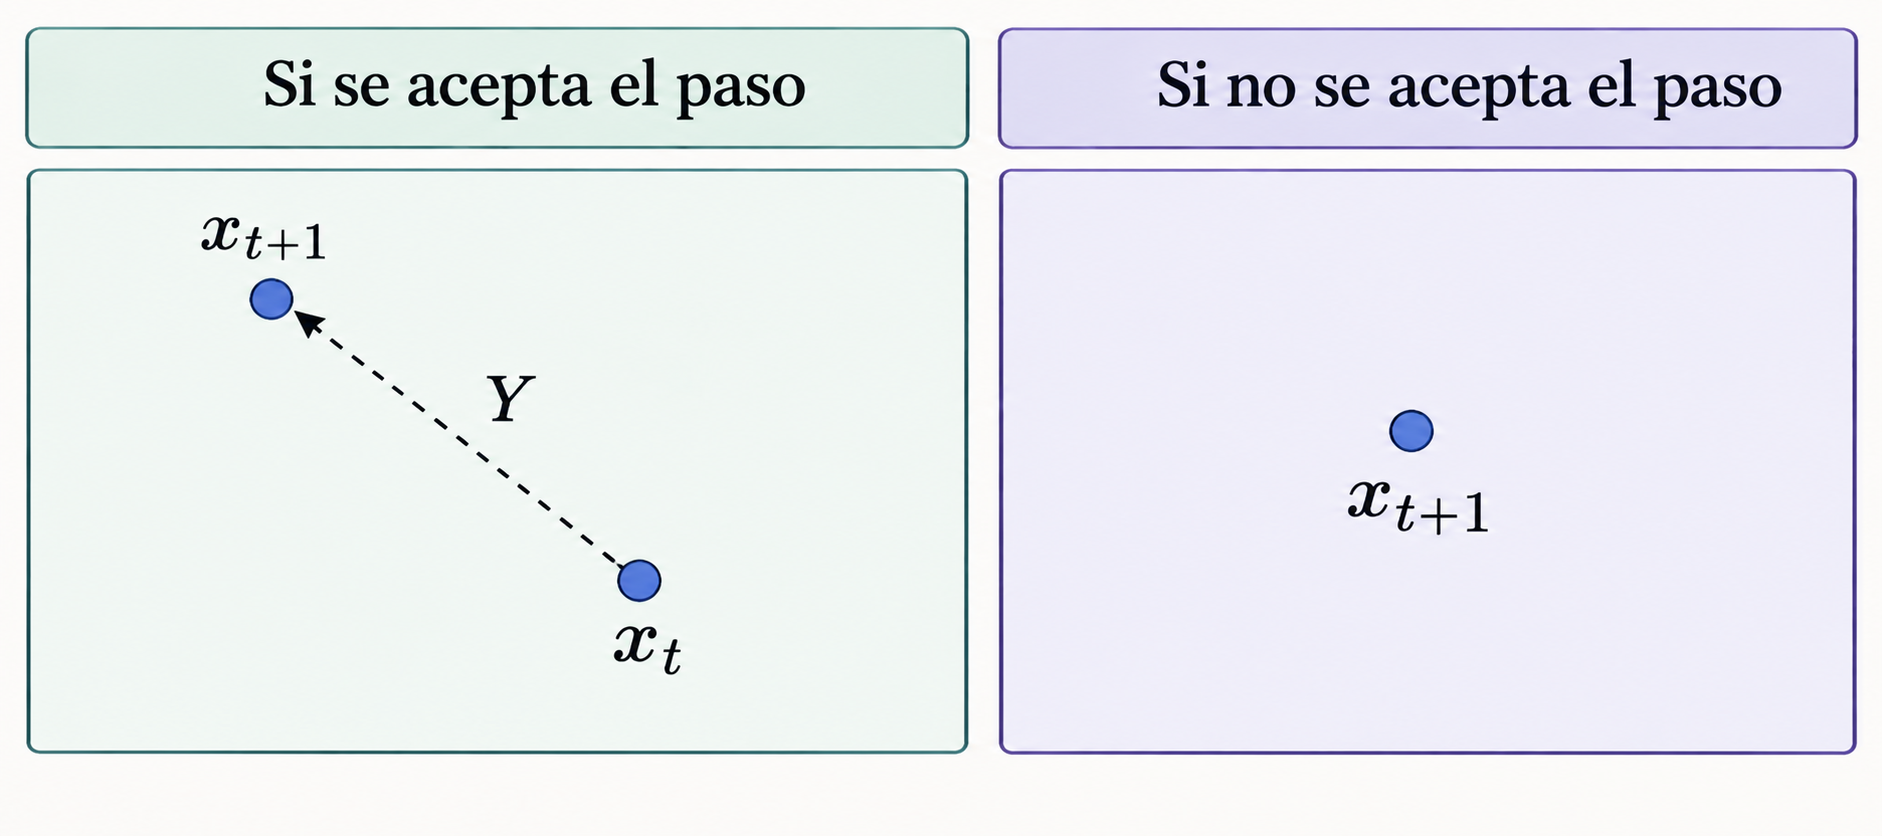

## <span style="color:purple;">**Caminata Aleatoria**</span>
Si se elije $q$ como una $N(0,σ)$, se tiene el sampler más simple, con: $$α(x,y)=min\{\frac{f(y)}{f(x)}, 1\} \quad y \quad Y= x+Z \quad Z∼(N(0,σ),N(0,σ)) $$


* <span style="color:red;">**Ejercicio**: Simular el vector $X=(x_1,x_2)$ que sigue el pdf:</span>

$$f(x)= C*exp (-\frac{x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2}{2})$$

$$C=\frac{1}{20216.335877}$$


In [74]:
# libreias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# esta librería sirve para resolver
# problemas de optimización matemática y búsqueda de raíces
from scipy import optimize
from scipy.integrate import quad
from scipy.optimize import minimize_scalar, brentq

Definimos la funcion principal:
$$f(x)= C*exp (-\frac{x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2}{2})$$

In [75]:
def densidad_objetivo(x):


    # Extraemos x1 y x2
    x1, x2 = x

    # Constante de normalización
    C = 1 / 20216.335877

    # Calculamos la densidad
    return C * np.exp(
        -(x1**2 * x2**2 + x1**2 + x2**2 - 8*x1 - 8*x2) / 2
    )


In [76]:
# Constante de normalización dada en el problema
C

4.946494785623807e-05

In [77]:
def f_normalizada(x1, x2): #Normalizamos
    return C * densidad_objetivo([x1, x2])

<span style="color:red;">**PROGRAMA: Metódo Metropoli-Hastings**</span>

*Seudocódigo*
1. Inicialización $X_1=(x_1,x_2).$ Hacer $t=1$
2. Generar $Z_1,Z_2 ∼ N(0,1)$
Sea $Z=Z_1,Z_2$ Y $Y= X_t+Z$
Calcular $α=α(X_t, Y)$
3. Generar $U∼U[0,1]$ sI $U<α.$ Hacer $X_{t+1}=Y$

Otro caso: Hacer $X_{t+1}=X_t$

4. Hacer $t=t+1$. Si $t=N$ (tamaño de la muestra) Detener
Otro caso. Regresar a $2$

In [78]:

def metropolis_hastings(estado_inicial, num_muestras, desv_propuesta=1.0):

    # 1. Inicialización

    # Creamos una matriz para almacenar las muestras.
    # Cada fila representa un estado X_t = (x1, x2)
    muestras = np.zeros((num_muestras, 2))

    # Definimos el estado inicial:
    # X_1 = (x1, x2)
    estado_actual = np.array(estado_inicial, dtype=float)

    # Guardamos el primer estado
    muestras[0] = estado_actual

    # Contador de muestras aceptadas
    aceptadas = 0



    # 2. Generar Z1, Z2 ~ N(0,1)

    # Comenzamos en t = 2 porque X_1 ya fue definido
    for t in range(1, num_muestras):

        # Generamos:
        # Z1, Z2 ~ N(0, sigma^2)
        #
        # donde sigma = desv_propuesta

        Z = np.random.normal(
            0,
            desv_propuesta,
            size=2
        )


        # Generar la propuesta:
        #
        # Y = Xt + Z

        estado_propuesto = estado_actual + Z


        # Calcular:
        #
        # alpha = min{ f(Y)/f(Xt), 1 }


        razon = (
            densidad_objetivo(estado_propuesto)
            /
            densidad_objetivo(estado_actual)
        )

        alpha = min(1.0, razon)

        # 3. Generar U ~ U[0,1]


        u = np.random.uniform(0, 1)

        # Si U < alpha:
        #
        # X_(t+1) = Y


        if u < alpha:

            estado_actual = estado_propuesto.copy()

            # Contamos la propuesta como aceptada
            aceptadas += 1



        # En otro caso:
        #
        # X_(t+1) = Xt
        #
        # No se modifica estado_actual


        # Guardamos el estado actual
        muestras[t] = estado_actual



    # Regresamos las muestras y la tasa de aceptación


    tasa_aceptacion = aceptadas / (num_muestras - 1)

    return muestras, tasa_aceptacion


Estado inicial  $$ [0,0]$$

Tamaño de nuestra muestra $$N = 100000$$

In [79]:

# Tamaño de la muestra
N = 100000

# Estado inicial:
# X1 = (0, 0)
estado_inicial = [0, 0]

# Desviación estándar de la propuesta
sigma = 1.0


# Ejecutamos Metropolis-Hastings
muestras, tasa_aceptacion = metropolis_hastings(
    estado_inicial,
    N,
    sigma
)


In [80]:


# Número de muestras y desviación de la propuesta
num_muestras = N
desv_propuesta = sigma

# Ejecutar el algoritmo
muestras_simuladas, tasa_aceptacion_sim = metropolis_hastings(
    estado_inicial,
    num_muestras,
    desv_propuesta
)


# Media
media_x1 = np.mean(muestras_simuladas[:, 0])
media_x2 = np.mean(muestras_simuladas[:, 1])

# Mediana
mediana_x1 = np.median(muestras_simuladas[:, 0])
mediana_x2 = np.median(muestras_simuladas[:, 1])


# Tabla con los resultados principales
resultados = pd.DataFrame({
    "Resultado": [
        "Tamaño de muestra",
        "Tasa de aceptación",
        "Media de X1",
        "Media de X2",
        "Mediana de X1",
        "Mediana de X2"
    ],

    "Valor": [
        num_muestras,
        f"{tasa_aceptacion_sim:.4f}",
        f"{media_x1:.4f}",
        f"{media_x2:.4f}",
        f"{mediana_x1:.4f}",
        f"{mediana_x2:.4f}"
    ]
})


# PRIMERAS 5 MUESTRAS

primeras_5 = pd.DataFrame(
    muestras_simuladas[:5],
    columns=["X1", "X2"]
)

primeras_5.insert(
    0,
    "Muestra",
    range(1, 6)
)


print("\n")
print("==========================================================")
print("             RESULTADOS METROPOLIS-HASTINGS")
print("==========================================================")

print("\nRESULTADOS GENERALES")
print(resultados.to_string(index=False))

print("\nPRIMERAS 5 MUESTRAS SIMULADAS")
print(primeras_5.to_string(index=False))

print("==========================================================")




             RESULTADOS METROPOLIS-HASTINGS

RESULTADOS GENERALES
         Resultado  Valor
 Tamaño de muestra 100000
Tasa de aceptación 0.3050
       Media de X1 1.7947
       Media de X2 1.9271
     Mediana de X1 1.1867
     Mediana de X2 1.5012

PRIMERAS 5 MUESTRAS SIMULADAS
 Muestra       X1       X2
       1 0.000000 0.000000
       2 0.000000 0.000000
       3 0.000000 0.000000
       4 0.313285 0.795577
       5 0.264463 1.182620


<span style="color:orange;">**Grafiquemos los histogramas y el mapa de dispersión**</span> para observar como caen estas simulaciones y como se acerca a la función principal.

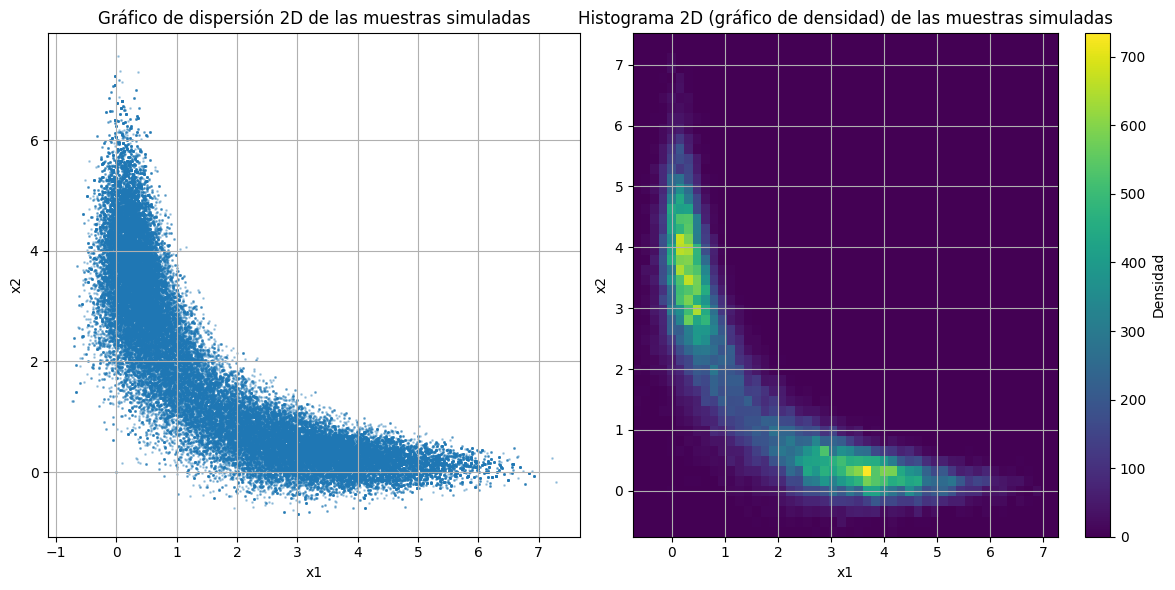

In [81]:

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(muestras_simuladas[:, 0], muestras_simuladas[:, 1], alpha=0.3, s=1)
plt.title('Gráfico de dispersión 2D de las muestras simuladas')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist2d(muestras_simuladas[:, 0], muestras_simuladas[:, 1], bins=50, cmap='viridis')
plt.colorbar(label='Densidad')
plt.title('Histograma 2D (gráfico de densidad) de las muestras simuladas')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)

plt.tight_layout()
plt.show()


De manera Visual tenemos:

* <span style="color:blue;">**Gráfico de dispersión 2D (izquierda):**</span>  Cada punto representa una de las muestras generadas. Lo primero que salta a la vista es que las muestras no se distribuyen uniformemente, sino que dibujan una forma curva que se asemeja a un "plátano" o bumerán. Además, se aprecian claramente dos zonas donde los puntos están muchísimo más acumulados o concentrados (una cerca de $x_1 \approx 0.3, x_2 \approx 3.7$$x_1 \approx 0.3, x_2 \approx 3.7$ y la otra simétrica cerca de $x_1 \approx 3.7, x_2 \approx 0.3$$x_1 \approx 3.7, x_2 \approx 0.3$).

* <span style="color:purple;">**Histograma 2D / Gráfico de densidad (derecha):**</span>  Esta gráfica confirma con colores la densidad de los puntos. Los colores más claros (amarillo/verde) indican las regiones con mayor frecuencia o probabilidad, mientras que los tonos oscuros (azul/morado) muestran zonas de baja probabilidad. Aquí se hace muy evidente la bimodalidad del sistema: existen dos máximos locales muy marcados (las dos modas reales de tu función objetivo).

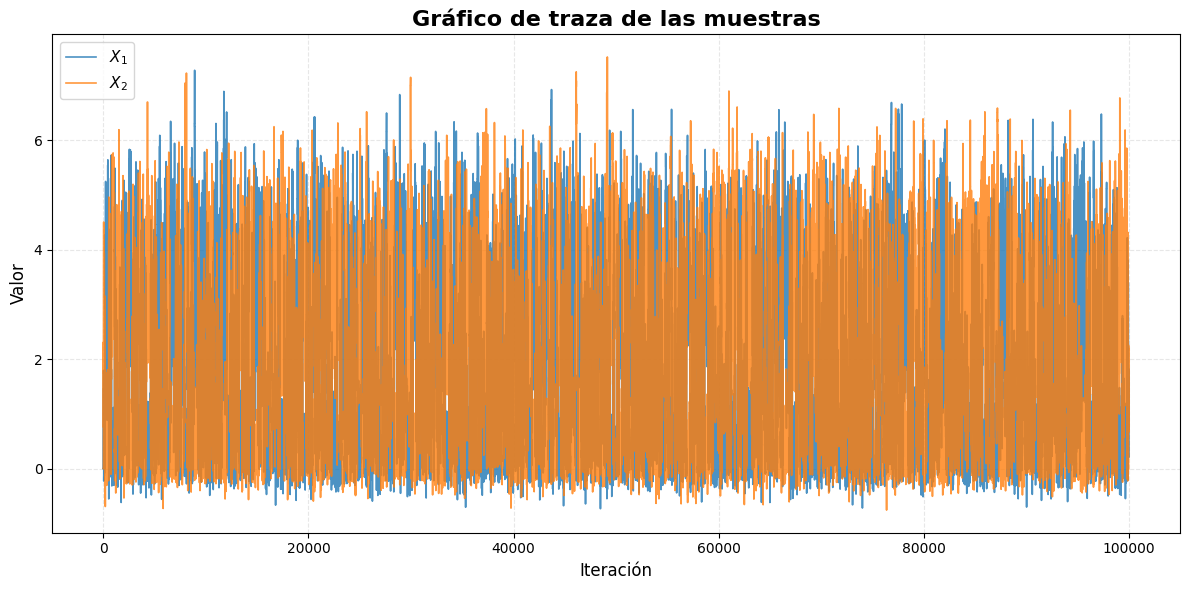

In [82]:

# GRÁFICO DE TRAZA

plt.figure(figsize=(12, 6))

plt.plot(
    muestras_simuladas[:, 0],
    label=r"$X_1$",
    linewidth=1.2,
    alpha=0.8
)

plt.plot(
    muestras_simuladas[:, 1],
    label=r"$X_2$",
    linewidth=1.2,
    alpha=0.8
)

plt.title(
    "Gráfico de traza de las muestras",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Iteración",
    fontsize=12
)

plt.ylabel(
    "Valor",
    fontsize=12
)

plt.legend(
    fontsize=11,
    frameon=True
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

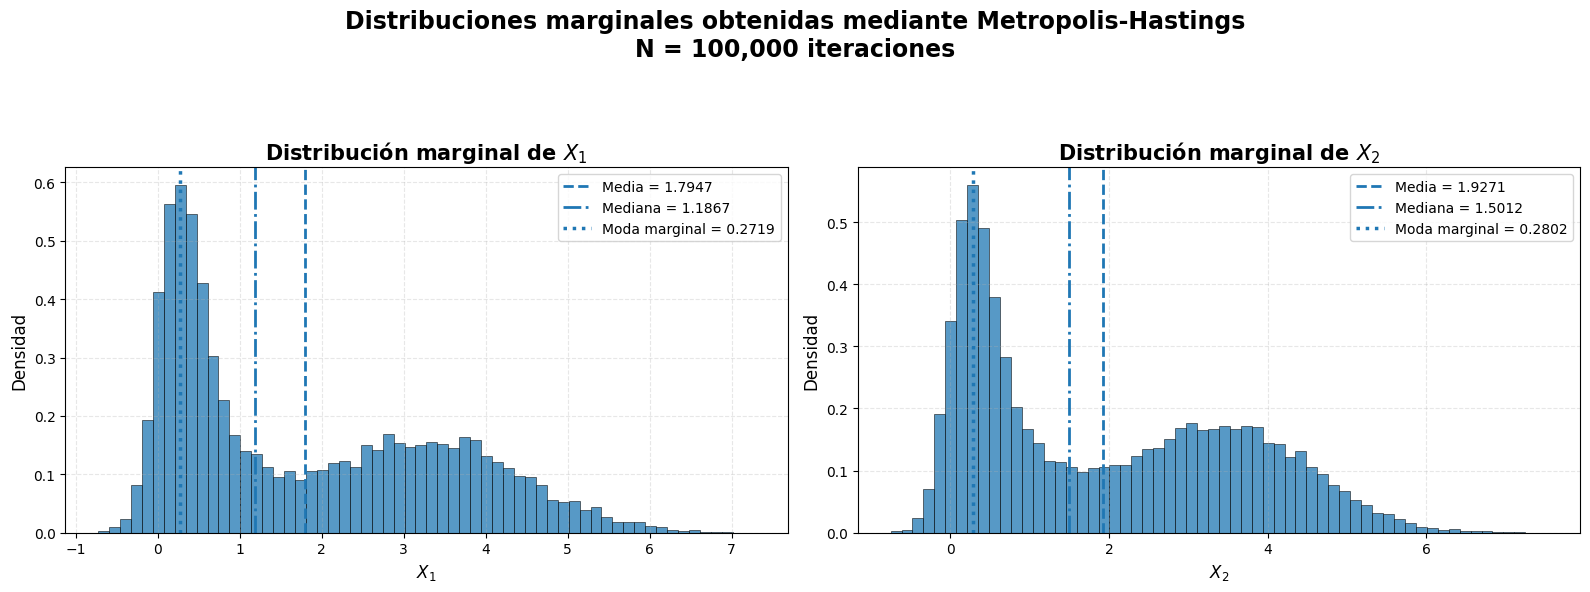

Número de iteraciones (N): 100000
Moda conjunta = (0.2719, 4.1441)


In [83]:

# GRÁFICAS MARGINALES DE X1 Y X2


# Datos
x1 = muestras_simuladas[:, 0]
x2 = muestras_simuladas[:, 1]

# Número de iteraciones
N = len(muestras_simuladas)



# ESTADÍSTICOS DE X1


media_x1 = np.mean(x1)
mediana_x1 = np.median(x1)

frecuencias_x1, limites_x1 = np.histogram(x1, bins=60, density=True)

indice_moda_x1 = np.argmax(frecuencias_x1)

moda_x1 = (
    limites_x1[indice_moda_x1]
    + limites_x1[indice_moda_x1 + 1]
) / 2



# ESTADÍSTICOS DE X2

media_x2 = np.mean(x2)
mediana_x2 = np.median(x2)

frecuencias_x2, limites_x2 = np.histogram(x2, bins=60, density=True)

indice_moda_x2 = np.argmax(frecuencias_x2)

moda_x2 = (
    limites_x2[indice_moda_x2]
    + limites_x2[indice_moda_x2 + 1]
) / 2

# GRÁFICAS JUNTAS


fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Título general
fig.suptitle(
    f"Distribuciones marginales obtenidas mediante Metropolis-Hastings\n"
    f"N = {N:,} iteraciones",
    fontsize=17,
    fontweight="bold"
)


# X1 - LADO IZQUIERDO

ax[0].hist(
    x1,
    bins=60,
    density=True,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.5
)

ax[0].axvline(
    media_x1,
    linestyle="--",
    linewidth=2,
    label=fr"Media = {media_x1:.4f}"
)

ax[0].axvline(
    mediana_x1,
    linestyle="-.",
    linewidth=2,
    label=fr"Mediana = {mediana_x1:.4f}"
)

ax[0].axvline(
    moda_x1,
    linestyle=":",
    linewidth=2.5,
    label=fr"Moda marginal = {moda_x1:.4f}"
)

ax[0].set_title(
    r"Distribución marginal de $X_1$",
    fontsize=15,
    fontweight="bold"
)

ax[0].set_xlabel(r"$X_1$", fontsize=12)
ax[0].set_ylabel("Densidad", fontsize=12)

ax[0].legend(fontsize=10)
ax[0].grid(True, linestyle="--", alpha=0.3)

# X2 - LADO DERECHO


ax[1].hist(
    x2,
    bins=60,
    density=True,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.5
)

ax[1].axvline(
    media_x2,
    linestyle="--",
    linewidth=2,
    label=fr"Media = {media_x2:.4f}"
)

ax[1].axvline(
    mediana_x2,
    linestyle="-.",
    linewidth=2,
    label=fr"Mediana = {mediana_x2:.4f}"
)

ax[1].axvline(
    moda_x2,
    linestyle=":",
    linewidth=2.5,
    label=fr"Moda marginal = {moda_x2:.4f}"
)

ax[1].set_title(
    r"Distribución marginal de $X_2$",
    fontsize=15,
    fontweight="bold"
)

ax[1].set_xlabel(r"$X_2$", fontsize=12)
ax[1].set_ylabel("Densidad", fontsize=12)

ax[1].legend(fontsize=10)
ax[1].grid(True, linestyle="--", alpha=0.3)


# Ajustar espacio para el título general
plt.tight_layout(rect=[0, 0, 1, 0.90])

plt.show()


# MODA CONJUNTA

frecuencias, bordes_x1, bordes_x2 = np.histogram2d(
    x1,
    x2,
    bins=60
)

indice = np.unravel_index(
    np.argmax(frecuencias),
    frecuencias.shape
)

moda_conjunta_x1 = (
    bordes_x1[indice[0]] + bordes_x1[indice[0] + 1]
) / 2

moda_conjunta_x2 = (
    bordes_x2[indice[1]] + bordes_x2[indice[1] + 1]
) / 2


print(f"Número de iteraciones (N): {N}")
print(
    f"Moda conjunta = "
    f"({moda_conjunta_x1:.4f}, {moda_conjunta_x2:.4f})"
)

A partir de los histogramas obtenidos mediante el método de **Metropolis-Hastings**, podemos observar que tanto $X_1$ como $X_2$ tienen un comportamiento **bimodal**. Es decir, los datos no se concentran en un solo valor, sino que presentan dos zonas principales donde se acumulan más muestras, aproximadamente alrededor de $0.3$ y $3.7$. Entre estas dos zonas se encuentra un valle, donde la cantidad de muestras disminuye considerablemente.

Al comparar la **media, mediana y moda marginal**, se observa que la media se encuentra cerca de esta región de menor concentración. Esto nos ayuda a entender que, aunque la media es una medida estadística importante, en este caso no representa necesariamente el valor más común de las variables. Debido a que la distribución tiene dos zonas de concentración, las modas nos permiten identificar mejor los valores donde se encuentran agrupadas las muestras.



## <span style="color:purple;">**Integración Numérica**</span>
Ahora, las vamos a obtener directamente de la **distribución objetivo** mediante. Después podemos colocarlas sobre los histogramas para comparar los valores teóricos con los obtenidos por Metropolis-Hastings.




#### CÁLCULO DE LOS VALORES REALES


* ¿Qué estamos haciendo matemáticamente?



Para $X_1$, primero obtenemos su densidad marginal integrando la densidad conjunta respecto de $x_2$:

$$
f_{X_1}(x_1)
=
\int_{-\infty}^{\infty}
f(x_1,x_2)\,dx_2.
$$

A partir de esta densidad marginal, la **media real** de $X_1$ se obtiene mediante la siguiente integral:

$$
E[X_1]
=
\int_{-\infty}^{\infty}
x_1 f_{X_1}(x_1)\,dx_1.
$$
La **mediana** se obtiene buscando el valor $m$ que cumple que la función de distribución acumulada sea igual a $0.5$:

$$
F_{X_1}(m)
=
\int_{-\infty}^{m}
f_{X_1}(x_1)\,dx_1
=
0.5.
$$

Por otro lado, la **moda marginal** corresponde al valor de $x_1$ que maximiza la densidad marginal:

$$
x_1^{*}
=
\underset{x_1}{\operatorname{arg\,max}}\,
f_{X_1}(x_1).
$$

El mismo procedimiento se realiza para obtener la media, mediana y moda marginal de $X_2$.

Finalmente, la **moda conjunta** corresponde al punto
$(x_1^*,x_2^*)$ donde la densidad conjunta alcanza su valor máximo:

$$
(x_1^*,x_2^*)
=
\underset{(x_1,x_2)}{\operatorname{arg\,max}}\,
f(x_1,x_2).
$$



In [84]:

# DENSIDADES MARGINALES

def densidad_marginal_x1(x1):

   # f_X1(x1) = integral de f(x1,x2) respecto de x2.

    resultado, error = quad(
        lambda x2: densidad_objetivo(x1, x2),
        -np.inf,
        np.inf
    )
    return resultado


def densidad_marginal_x2(x2):

    # f_X2(x2) = integral de f(x1,x2) respecto de x1.

    resultado, error = quad(
        lambda x1: densidad_objetivo(x1, x2),
        -np.inf,
        np.inf
    )
    return resultado


In [86]:
# Redefinimos las densidades marginales corrigiendo el paso de parámetros a [x1, x2]
def densidad_marginal_x1(x1):
    resultado, error = quad(
        lambda x2: densidad_objetivo([x1, x2]),
        -np.inf,
        np.inf
    )
    return resultado

def densidad_marginal_x2(x2):
    resultado, error = quad(
        lambda x1: densidad_objetivo([x1, x2]),
        -np.inf,
        np.inf
    )
    return resultado

# MEDIA REAL MEDIANTE INTEGRACIÓN NUMÉRICA

# E[X1]
media_real_x1, error = quad(
    lambda x1: x1 * densidad_marginal_x1(x1),
    -np.inf,
    np.inf
)

# E[X2]
media_real_x2, error = quad(
    lambda x2: x2 * densidad_marginal_x2(x2),
    -np.inf,
    np.inf
)

In [87]:

# MEDIANA REAL MEDIANTE INTEGRACIÓN NUMÉRICA


def cdf_x1(x):

    # Función de distribución acumulada de X1.

    resultado, error = quad(
        lambda u: densidad_marginal_x1(u),
        -np.inf,
        x
    )
    return resultado


In [88]:

def cdf_x2(x):

    # Función de distribución acumulada de X2.

    resultado, error = quad(
        lambda u: densidad_marginal_x2(u),
        -np.inf,
        x
    )
    return resultado


# Mediana: F(x) = 0.5
mediana_real_x1 = brentq(
    lambda x: cdf_x1(x) - 0.5,
    -2,
    6
)

mediana_real_x2 = brentq(
    lambda x: cdf_x2(x) - 0.5,
    -2,
    6
)



In [89]:

# MODA MARGINAL REAL


resultado_moda_x1 = minimize_scalar(
    lambda x: -densidad_marginal_x1(x),
    bounds=(-2, 6),
    method="bounded"
)

moda_real_x1 = resultado_moda_x1.x


resultado_moda_x2 = minimize_scalar(
    lambda x: -densidad_marginal_x2(x),
    bounds=(-2, 6),
    method="bounded"
)

moda_real_x2 = resultado_moda_x2.x



In [91]:

# MODA CONJUNTA REAL

def funcion_negativa(x):
    # Pasamos 'x' directamente como un único argumento (que contiene x1 y x2)
    return -densidad_objetivo(x)


# Como la distribución tiene dos zonas de concentración,
# buscamos los máximos desde diferentes puntos iniciales.

from scipy.optimize import minimize

puntos_iniciales = [
    [0.3, 0.3],
    [0.3, 3.7],
    [3.7, 0.3],
    [3.7, 3.7]
]

modas_conjuntas = []

for punto in puntos_iniciales:

    resultado = minimize(
        funcion_negativa,
        punto,
        method="Nelder-Mead"
    )

    modas_conjuntas.append(
        (resultado.x[0], resultado.x[1], -resultado.fun)
    )


# Ordenar de acuerdo con la densidad
modas_conjuntas.sort(key=lambda x: x[2], reverse=True)



In [92]:
# Resultados obtenidos

print("\n==============================================================")
print("          COMPARACIÓN: VALORES REALES VS SIMULACIÓN")
print("==============================================================\n")

print(
    tabla_resultados.to_string(
        index=False,
        formatters={
            "Valor real": "{:.6f}".format,
            "Valor simulado": "{:.6f}".format
        }
    )
)

print("\n==============================================================")


          COMPARACIÓN: VALORES REALES VS SIMULACIÓN

     Estadístico Valor real Valor simulado  Diferencia  Error absoluto
        Media X1   1.859966       1.926930    0.066964        0.066964
        Media X2   1.859966       1.788670   -0.071296        0.071296
      Mediana X1   1.346820       1.511912    0.165092        0.165092
      Mediana X2   1.346820       1.189514   -0.157306        0.157306
Moda marginal X1   3.376359       0.191682   -3.184677        3.184677
Moda marginal X2   3.376359       0.239360   -3.136999        3.136999
Moda conjunta X1   3.732067       3.606324   -0.125742        0.125742
Moda conjunta X2   0.267953       0.307718    0.039765        0.039765



Estos valores no se obtienen directamente de las $N$ muestras generadas mediante Metropolis-Hastings. En este caso, se calculan directamente a partir de la **distribución objetivo**, utilizando integración y optimización numérica. Esto permite comparar los valores reales con los valores estimados a partir de la simulación y evaluar qué tan bien el algoritmo de Metropolis-Hastings reproduce la distribución objetivo.

###<span style="color:teal;">Graficamos la grafica real de la función</span>

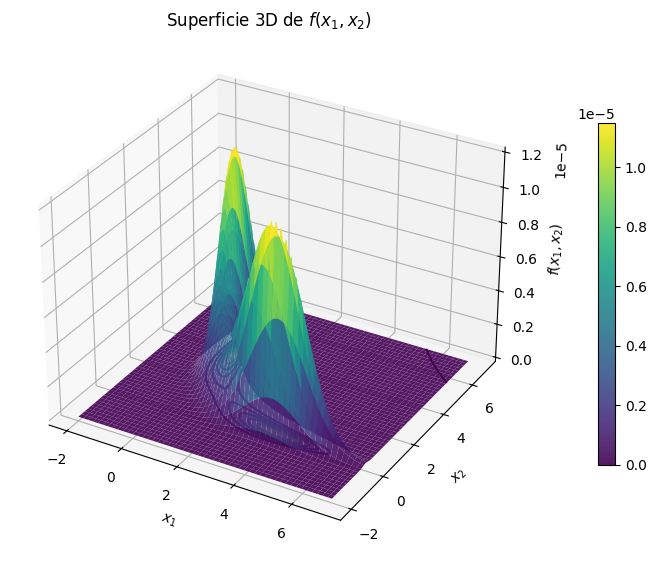

In [94]:
x1_malla = np.linspace(-2, 7, 250)
x2_malla = np.linspace(-2, 7, 250)
X1, X2 = np.meshgrid(x1_malla, x2_malla)

# Ajustamos f_normalizada para que use el formato correcto de dos argumentos x1, x2 agrupados en una lista o arreglo
def f_normalizada_corregida(x1, x2):
    return C * densidad_objetivo(np.array([x1, x2]))

Z = f_normalizada_corregida(X1, X2)

fig = plt.figure(figsize=(14, 6))

ax = fig.add_subplot(1, 2, 1, projection='3d')
superficie = ax.plot_surface(X1, X2, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax.contour(X1, X2, Z, zdir='z', offset=0, cmap='viridis')   # contornos en la base
ax.set_title('Superficie 3D de $f(x_1,x_2)$')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$f(x_1,x_2)$')
ax.view_init(elev=30, azim=-60)
fig.colorbar(superficie, ax=ax, shrink=0.6, pad=0.1)

plt.tight_layout()
plt.show()

In [95]:
import plotly.graph_objects as go #libreria para poder movilizar la grafica

# Gráfica interactiva utilizando X1 y X2 definidos en la celda anterior
fig = go.Figure(data=[
    go.Surface(
        x=X1,
        y=X2,
        z=Z,
        colorscale="Viridis"
    )
])

fig.update_layout(
    title="Vista interactiva de f(x,y)=C·exp(-(x²y²+x²+y²-8x-8y)/2)",
    width=900,
    height=700,
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="f(x,y)"
    )
)

fig.show()

Al observar la gráfica de la superficie 3D de la densidad normalizada $f(x_1, x_2)$$f(x_1, x_2)$, podemos destacar las siguientes características clave sobre el comportamiento del vector aleatorio $X = (x_1, x_2)$$X = (x_1, x_2)$:

1. Estructura Bimodal (Dos picos principales)
La característica más sobresaliente es la bimodalidad. No hay un único punto más probable, sino dos picos simétricos muy claros (modas conjuntas) que se elevan sobre la superficie. Estos dos máximos locales representan las combinaciones de mayor probabilidad y ocurren aproximadamente en:

El primer pico cerca de: $(x_1 \approx 3.73,\; x_2 \approx 0.27)$$(x_1 \approx 3.73,\; x_2 \approx 0.27)$
El segundo pico (simétrico) cerca de: $(x_1 \approx 0.27,\; x_2 \approx 3.73)$$(x_1 \approx 0.27,\; x_2 \approx 3.73)$
2. Forma de Búmeran o "Plátano" (Correlación no lineal)
Si miras las curvas de nivel proyectadas en la base del gráfico (los contornos planos), la distribución no tiene forma elíptica ni circular (que denotaría una correlación lineal estándar). En su lugar, describe una trayectoria curva con forma de búmeran que conecta ambos picos principales. Esto nos indica una fuerte asociación no lineal entre $X_1$$X_1$ y $X_2$$X_2$.

3. Presencia de un "Valle" Central (Zona de baja probabilidad)
Justo en medio de los dos picos (alrededor de la diagonal $x_1 = x_2$$x_1 = x_2$) se observa un pronunciado valle o depresión. Aunque matemáticamente es el camino que conecta ambas zonas de concentración, la densidad aquí es significativamente menor. Esto explica perfectamente por qué tus simulaciones MCMC de Metropolis-Hastings muestran pocos puntos en esta zona central y por qué la media teórica se sitúa en esta región de baja probabilidad, convirtiéndola en un estadístico poco representativo de los valores más comunes.

4. Caída rápida hacia cero (Colas ligeras)
Fuera de la estructura en forma de búmeran, la densidad cae de manera sumamente rápida a cero. Esto se debe al término cuadrático dominante en el exponente de la función original, el cual penaliza drásticamente cualquier valor lejano a la región central.

# <span style="color:green;">**Conlusión:**</span>
En conclusión, el algoritmo **Metropolis-Hastings** permitió obtener muestras de la distribución. Los resultados de la simulación fueron cercanos a los valores reales de media, mediana y moda.

También se observó que el método necesita suficientes iteraciones y un buen valor de $\sigma$, ya que una elección inadecuada puede hacer que la cadena avance muy lento o rechace muchas propuestas. A pesar de esto, el algoritmo resultó útil y práctico para este ejercicio.